## Jet Image Pre-training with Vision Transformer

This notebook sets up a self-supervised pre-training pipeline for jet images using an unlabelled HDF5 dataset.

1. **Data Inspection** – Open the HDF5 file and examine the structure/shape of the `jet` dataset (125×125×8 images with 8 channels).
2. **PyTorch Dataset** – Define `JetUnlabelledDataset`, which lazily loads jet images, converts them to `(C, H, W)` tensors, and applies zero-mean/unit-variance normalization.
3. **Train / Val Split & DataLoaders** – Split the dataset 95/5 into training and validation sets and wrap them in `DataLoader`s for batched iteration.

In [ ]:
import h5py

with h5py.File('data/Dataset_Specific_Unlabelled.h5', 'r') as f:
    print("Top-level keys:", list(f.keys()))

    jet = f['jet']
    print("Type of 'jet':", type(jet))

    # If it's a dataset:
    if isinstance(jet, h5py.Dataset):
        print("Shape:", jet.shape)
        first = jet[0]
        print("First item shape:", first.shape)

    # If it's a group (folder), inspect deeper:
    if isinstance(jet, h5py.Group):
        print("Keys inside 'jet':", list(jet.keys()))

Top-level keys: ['jet']
Type of 'jet': <class 'h5py._hl.dataset.Dataset'>
Shape: (60000, 125, 125, 8)
First item shape: (125, 125, 8)


In [3]:
import h5py
import torch
from torch.utils.data import Dataset, DataLoader

class JetUnlabelledDataset(Dataset):
    def __init__(self, h5_path):
        self.h5_path = h5_path
        self.file = None  # opened lazily

        # read shape without keeping file open
        with h5py.File(h5_path, "r") as f:
            self.length = f["jet"].shape[0]

    def __len__(self):
        return self.length

    def __getitem__(self, idx):
        # open file inside worker if needed
        if self.file is None:
            self.file = h5py.File(self.h5_path, "r")
        
        x = self.file["jet"][idx]  # (125,125,8)
        x = torch.tensor(x, dtype=torch.float32)

        # convert to (C,H,W)
        x = x.permute(2, 0, 1)

        # optional: simple normalization
        x = (x - x.mean()) / (x.std() + 1e-6)

        return x

In [ ]:
from torch.utils.data import random_split

dataset = JetUnlabelledDataset("data/Dataset_Specific_Unlabelled.h5")

val_size = int(0.05 * len(dataset))
train_size = len(dataset) - val_size

train_ds, val_ds = random_split(
    dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=32, shuffle=False, num_workers=0)

## Sanity Check: Visualizing Jet Channels

Before training any model, we must verify that the input data looks reasonable.

Each jet sample has shape (8, 125, 125), meaning:
- 8 feature channels
- 125×125 spatial grid per channel

These are not RGB images. Each channel encodes detector-level physical information.
If the data contains mostly zeros, extreme outliers, or unexpected structure,
a transformer may learn meaningless patterns.

We will:
- Sample a random jet
- Visualize a few of its channels
- Inspect value ranges

This prevents silent failure during training.

Sample shape: torch.Size([8, 125, 125])
Min value: -0.08721346408128738
Max value: 22.801904678344727
Mean value: -1.8066407037053978e-08
Std value: 0.9999998807907104


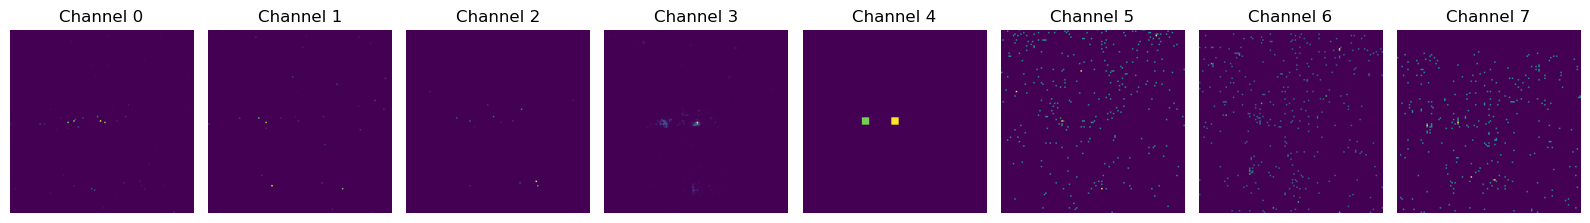

In [6]:
import matplotlib.pyplot as plt
import random

# get one random sample from training dataset
idx = random.randint(0, len(train_ds)-1)
sample = train_ds[idx]   # shape: (8,125,125)

print("Sample shape:", sample.shape)
print("Min value:", sample.min().item())
print("Max value:", sample.max().item())
print("Mean value:", sample.mean().item())
print("Std value:", sample.std().item())

# visualize first 4 channels
num_channels_to_plot = 8

fig, axes = plt.subplots(1, num_channels_to_plot, figsize=(16,4))

for i in range(num_channels_to_plot):
    axes[i].imshow(sample[i].cpu(), cmap="viridis")
    axes[i].set_title(f"Channel {i}")
    axes[i].axis("off")

plt.tight_layout()
plt.show()

In [10]:
import torch
import torch.nn as nn

class PatchEmbed(nn.Module):
    def __init__(self, in_ch=8, embed_dim=256, patch=5):
        super().__init__()
        self.proj = nn.Conv2d(in_ch, embed_dim,
                              kernel_size=patch,
                              stride=patch)

    def forward(self, x):
        x = self.proj(x)          # (B, embed_dim, 25, 25)
        x = x.flatten(2)          # (B, embed_dim, 625)
        x = x.transpose(1, 2)     # (B, 625, embed_dim)
        return x

# test
patch_embed = PatchEmbed()
batch = next(iter(train_loader))

tokens = patch_embed(batch)
print("Input batch shape:", batch.shape)
print("Token shape:", tokens.shape)

Input batch shape: torch.Size([32, 8, 125, 125])
Token shape: torch.Size([32, 625, 256])


## Pretraining: Masked Autoencoder for Jet Representation Learning

We pretrain a Vision Transformer encoder on the unlabelled jet dataset using a masked reconstruction objective.

Each jet image (8 × 125 × 125) is split into 5×5 patches → 625 tokens.

During training:
- 60% of patches are randomly masked
- Encoder processes only visible patches
- A lightweight decoder reconstructs the original patches
- Loss = Mean Squared Error between reconstructed and original patches

Why this works:
The model must learn global jet structure to reconstruct missing regions.
This produces useful representations for downstream tasks like
mass regression and classification.

After pretraining, we will:
- Save encoder weights
- Fine-tune on labelled dataset
- Compare against training from scratch

In [30]:
import torch
import torch.nn as nn
import torch.optim as optim

if torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

# -----------------------
# Patch embedding
# -----------------------
class PatchEmbed(nn.Module):
    def __init__(self, in_ch=8, embed_dim=256, patch=5):
        super().__init__()
        self.patch = patch
        self.proj = nn.Conv2d(in_ch, embed_dim,
                              kernel_size=patch,
                              stride=patch)

    def forward(self, x):
        x = self.proj(x)                        # (B, D, 25, 25)
        B, D, H, W = x.shape
        x = x.permute(0, 2, 3, 1).contiguous()  # (B, 25, 25, D)
        x = x.reshape(B, H * W, D)              # (B, 625, D)
        return x

# -----------------------
# Attention block (stable)
# -----------------------
class Attention(nn.Module):
    def __init__(self, dim, heads=8):
        super().__init__()
        self.norm = nn.LayerNorm(dim)
        self.attn = nn.MultiheadAttention(
            embed_dim=dim,
            num_heads=heads,
            batch_first=True
        )

    def forward(self, x):
        y = self.norm(x)
        y, _ = self.attn(y, y, y, need_weights=False)
        return y

class Block(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.attn = Attention(dim)
        self.ff = nn.Sequential(
            nn.Linear(dim, dim*4),
            nn.GELU(),
            nn.Linear(dim*4, dim)
        )
        self.n2 = nn.LayerNorm(dim)

    def forward(self,x):
        x = x + self.attn(x)
        x = x + self.ff(self.n2(x))
        return x

# -----------------------
# Encoder
# -----------------------
class Encoder(nn.Module):
    def __init__(self, dim=256, depth=4):
        super().__init__()
        self.patch = PatchEmbed()
        self.pos = nn.Parameter(torch.randn(1, 625, dim))
        self.blocks = nn.Sequential(*[Block(dim) for _ in range(depth)])
        self.norm = nn.LayerNorm(dim)

    def forward(self, x):
        x = self.patch(x)
        x = x + self.pos
        x = self.blocks(x)
        x = self.norm(x)
        return x

# -----------------------
# MAE model
# -----------------------
class MAE(nn.Module):
    def __init__(self, dim=256, mask_ratio=0.6):
        super().__init__()
        self.encoder = Encoder(dim)
        self.decoder = nn.Sequential(
            nn.Linear(dim, dim),
            nn.GELU(),
            nn.Linear(dim, 8*5*5)
        )
        self.mask_ratio = mask_ratio
        self.patch_size = 5

    def patchify(self, imgs):
        B, C, H, W = imgs.shape
        p = self.patch_size
        h, w = H // p, W // p
        x = imgs.reshape(B, C, h, p, w, p)
        x = x.permute(0, 2, 4, 1, 3, 5).contiguous()  # (B, h, w, C, p, p)
        x = x.reshape(B, h * w, C * p * p)
        return x

    def forward(self, x):
        B = x.size(0)

        target = self.patchify(x)
        tokens = self.encoder.patch(x)

        N = tokens.size(1)
        mask_count = int(N * self.mask_ratio)

        noise = torch.rand(B, N, device=x.device)
        ids = torch.argsort(noise, dim=1)
        keep = ids[:, mask_count:]

        visible = torch.gather(
            tokens, 1,
            keep.unsqueeze(-1).expand(-1, -1, tokens.size(-1))
        )

        encoded = self.encoder.blocks(
            visible + self.encoder.pos[:, :visible.size(1)]
        )
        encoded = self.encoder.norm(encoded)

        recon_visible = self.decoder(encoded)

        target_visible = torch.gather(
            target, 1,
            keep.unsqueeze(-1).expand(-1, -1, target.size(-1))
        )

        loss = ((recon_visible - target_visible)**2).mean()
        return loss

Using device: cpu


Epoch 1/5: 100%|██████████| 1782/1782 [08:22<00:00,  3.55it/s, loss=0.0425]


Epoch 1: Train=0.1902 | Val=0.0714


Epoch 2/5: 100%|██████████| 1782/1782 [08:13<00:00,  3.61it/s, loss=0.0391]


Epoch 2: Train=0.0589 | Val=0.0490


...

Epoch 3: Train=0.0420 | Val=0.0365


Epoch 4/5: 100%|██████████| 1782/1782 [08:19<00:00,  3.57it/s, loss=0.034] 


Epoch 4: Train=0.0321 | Val=0.0289


Epoch 5/5: 100%|██████████| 1782/1782 [08:15<00:00,  3.60it/s, loss=0.0245]


Epoch 5: Train=0.0259 | Val=0.0234


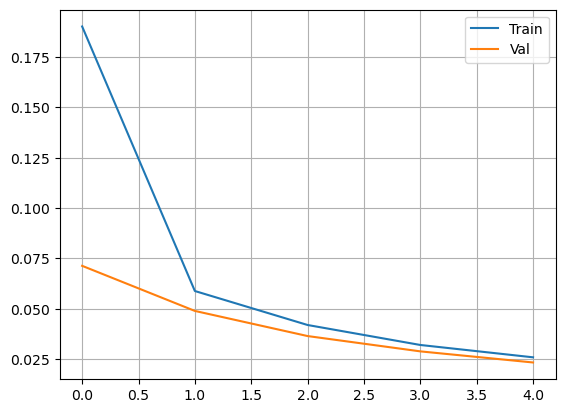

In [31]:
from tqdm import tqdm
import matplotlib.pyplot as plt

# device detection (use CUDA if available, otherwise CPU)
if torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print("Using device:", device)

model = MAE().to(device)
opt = torch.optim.Adam(model.parameters(), lr=1e-4)

epochs = 5
train_history = []
val_history = []

for epoch in range(epochs):
    model.train()
    train_loss = 0

    loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}")

    for batch in loop:
        batch = batch.to(device)

        loss = model(batch)

        opt.zero_grad()
        loss.backward()
        opt.step()

        train_loss += loss.item()
        loop.set_postfix(loss=loss.item())

    train_loss /= len(train_loader)
    train_history.append(train_loss)

    model.eval()
    val_loss = 0
    with torch.no_grad():
        for batch in val_loader:
            batch = batch.to(device)
            loss = model(batch)
            val_loss += loss.item()

    val_loss /= len(val_loader)
    val_history.append(val_loss)

    print(f"Epoch {epoch+1}: Train={train_loss:.4f} | Val={val_loss:.4f}")

torch.save(model.encoder.state_dict(), "pretrained_encoder.pt")

plt.plot(train_history, label="Train")
plt.plot(val_history, label="Val")
plt.legend()
plt.grid(True)
plt.show()